# ❤️‍🩹 Mental Health & Behavioral Risk Analysis: Machine Learning & Key Insights

---

 **📌 Project Overview** 
 
 This project predicts three mental health conditions: **Depression**, **Anxiety**, and **Burnout** based on daily lifestyle habits. Using a **Machine Learning Pipeline** and **LightGBM**, the goal is to identify the most important factors that affect our mental well-being.



 **📚 Data Source**
- **Dataset**: Mental Health and Behavioral Risk Dataset (2,000 Samples)
- **Source**: [Kaggle - Mental Health and Behavioral Risk Dataset](https://www.kaggle.com/datasets/abrerjawod/mental-health-and-behavioral-risk-dataset)

# Setup Environment

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter as kda
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, PowerTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import confusion_matrix, f1_score, classification_report, roc_curve, auc
import lightgbm as lgb
import optuna
import warnings

optuna.logging.set_verbosity(optuna.logging.WARNING) # Hide Log while Trial
warnings.filterwarnings('ignore')


In [7]:
# Load the mental health dataset from Kaggle
df = kagglehub.dataset_load(
    kda.PANDAS
    , 'abrerjawod/mental-health-and-behavioral-risk-dataset'
    , 'mental_health_lifestyle_2000.csv'
)

# Rename column names to lowercase snake_case, and drop the identifier column `person_id`
df.columns = df.columns.str.lower().str.strip().str.replace(' ','_')
df = df.drop('person_id',axis=1)
df.head()


,age,gender,occupation,daily_screen_time,social_media_usage,night_usage,sleep_hours,stress_level,work_study_hours,physical_activity,social_interaction_score,caffeine_intake,smoking,alcohol,depression,anxiety,burnout
0,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


# Data Cleaning  

In [8]:
# Print column profiles and structural types.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2000 non-null   int64  
 1   gender                    2000 non-null   str    
 2   occupation                2000 non-null   str    
 3   daily_screen_time         2000 non-null   float64
 4   social_media_usage        2000 non-null   float64
 5   night_usage               2000 non-null   int64  
 6   sleep_hours               2000 non-null   float64
 7   stress_level              2000 non-null   int64  
 8   work_study_hours          2000 non-null   float64
 9   physical_activity         2000 non-null   str    
 10  social_interaction_score  2000 non-null   int64  
 11  caffeine_intake           2000 non-null   int64  
 12  smoking                   2000 non-null   int64  
 13  alcohol                   2000 non-null   int64  
 14  depression         

In [9]:
# Count the number of missing (null) values in all columns.
df.isna().sum()


age                         0
gender                      0
occupation                  0
daily_screen_time           0
social_media_usage          0
night_usage                 0
sleep_hours                 0
stress_level                0
work_study_hours            0
physical_activity           0
social_interaction_score    0
caffeine_intake             0
smoking                     0
alcohol                     0
depression                  0
anxiety                     0
burnout                     0
dtype: int64

In [10]:
# Preview the head of the cleaned dataframe.
df.head()


,age,gender,occupation,daily_screen_time,social_media_usage,night_usage,sleep_hours,stress_level,work_study_hours,physical_activity,social_interaction_score,caffeine_intake,smoking,alcohol,depression,anxiety,burnout
0,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


# EDA

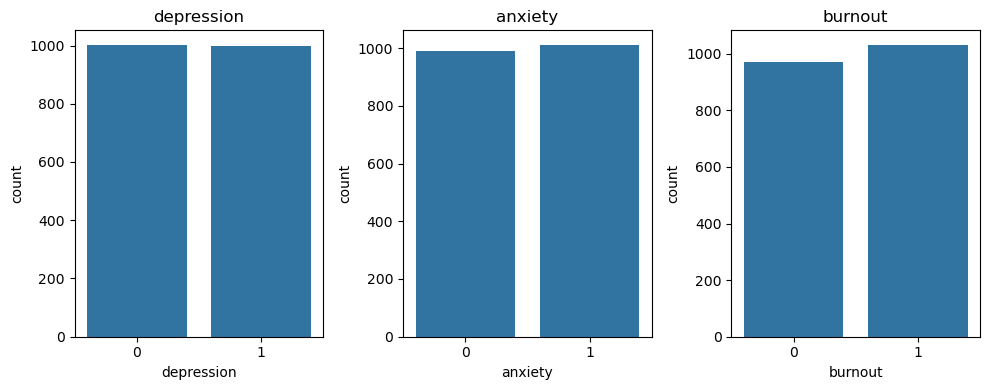

In [11]:
# Visualize class balances for the target variables (`depression`, `anxiety`, and `burnout`) using Seaborn count plots.
y_list = ['depression','anxiety','burnout']

fig, ax = plt.subplots(1,3,figsize=(10,4))
for i,y in enumerate(y_list):
    sns.countplot(df, x=y, ax=ax[i])
    ax[i].set_title(y)

plt.tight_layout()
plt.show()


- The classes are highly balanced, so there is no need to adjust model parameters to handle class imbalance.

# Build Model, Optimize and Evaluation for 3 Targats

In [12]:
# Convert numeric target labels (0 and 1) to semantic text strings ('No' and 'Yes').
for y in y_list:
    df[y] = np.where(df[y] == 1, 'Yes', 'No')
df.info() # Check Data Type


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       2000 non-null   int64  
 1   gender                    2000 non-null   str    
 2   occupation                2000 non-null   str    
 3   daily_screen_time         2000 non-null   float64
 4   social_media_usage        2000 non-null   float64
 5   night_usage               2000 non-null   int64  
 6   sleep_hours               2000 non-null   float64
 7   stress_level              2000 non-null   int64  
 8   work_study_hours          2000 non-null   float64
 9   physical_activity         2000 non-null   str    
 10  social_interaction_score  2000 non-null   int64  
 11  caffeine_intake           2000 non-null   int64  
 12  smoking                   2000 non-null   int64  
 13  alcohol                   2000 non-null   int64  
 14  depression         


 Predict >> depression 
Best F1 Score: 0.61
Best Params: {'n_estimators': 862, 'learning_rate': 0.0051816578497445006, 'num_leaves': 150, 'max_depth': 3}

 ==================== Evaluation ====================
f1_score (Test Set): 0.61
              precision    recall  f1-score   support

          No       0.62      0.60      0.61       250
         Yes       0.61      0.63      0.62       250

    accuracy                           0.61       500
   macro avg       0.61      0.61      0.61       500
weighted avg       0.61      0.61      0.61       500



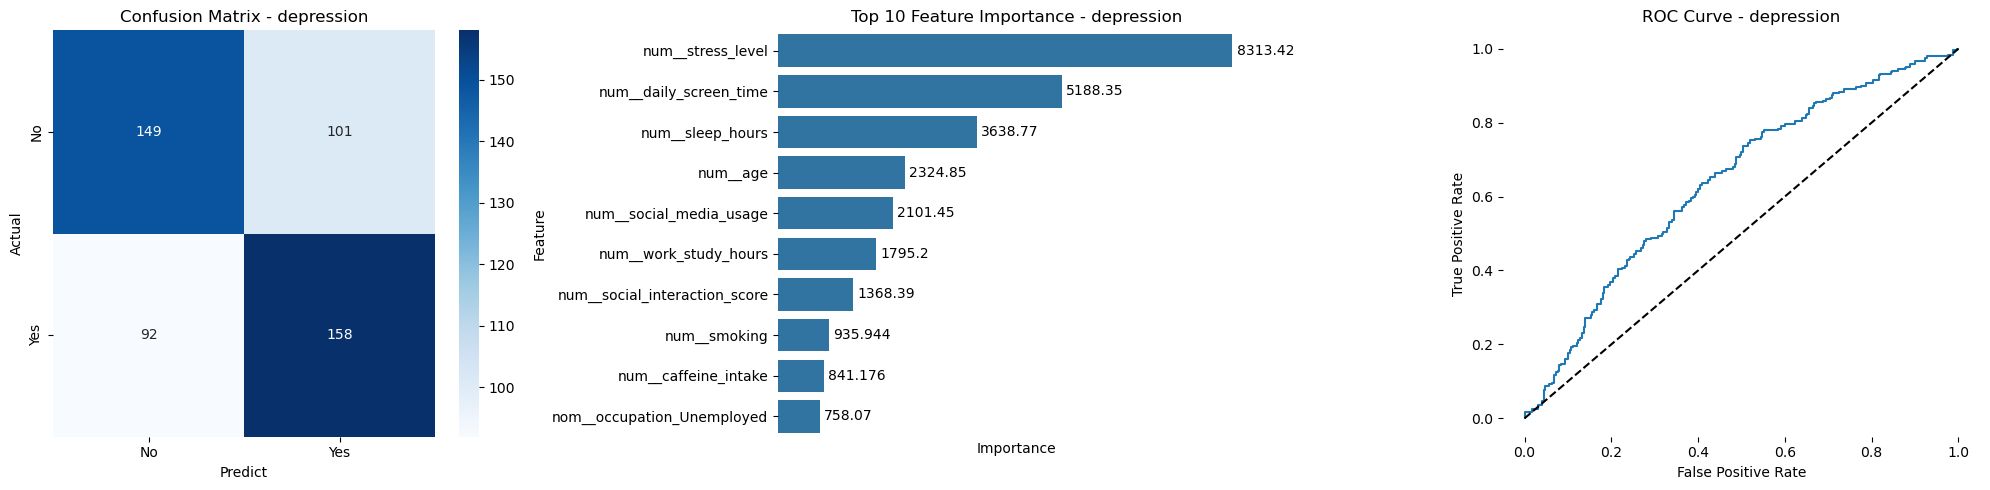


 Predict >> anxiety 
Best F1 Score: 0.62
Best Params: {'n_estimators': 594, 'learning_rate': 0.0035665047827877845, 'num_leaves': 23, 'max_depth': 47}

 ==================== Evaluation ====================
f1_score (Test Set): 0.63
              precision    recall  f1-score   support

          No       0.63      0.61      0.62       247
         Yes       0.63      0.65      0.64       253

    accuracy                           0.63       500
   macro avg       0.63      0.63      0.63       500
weighted avg       0.63      0.63      0.63       500



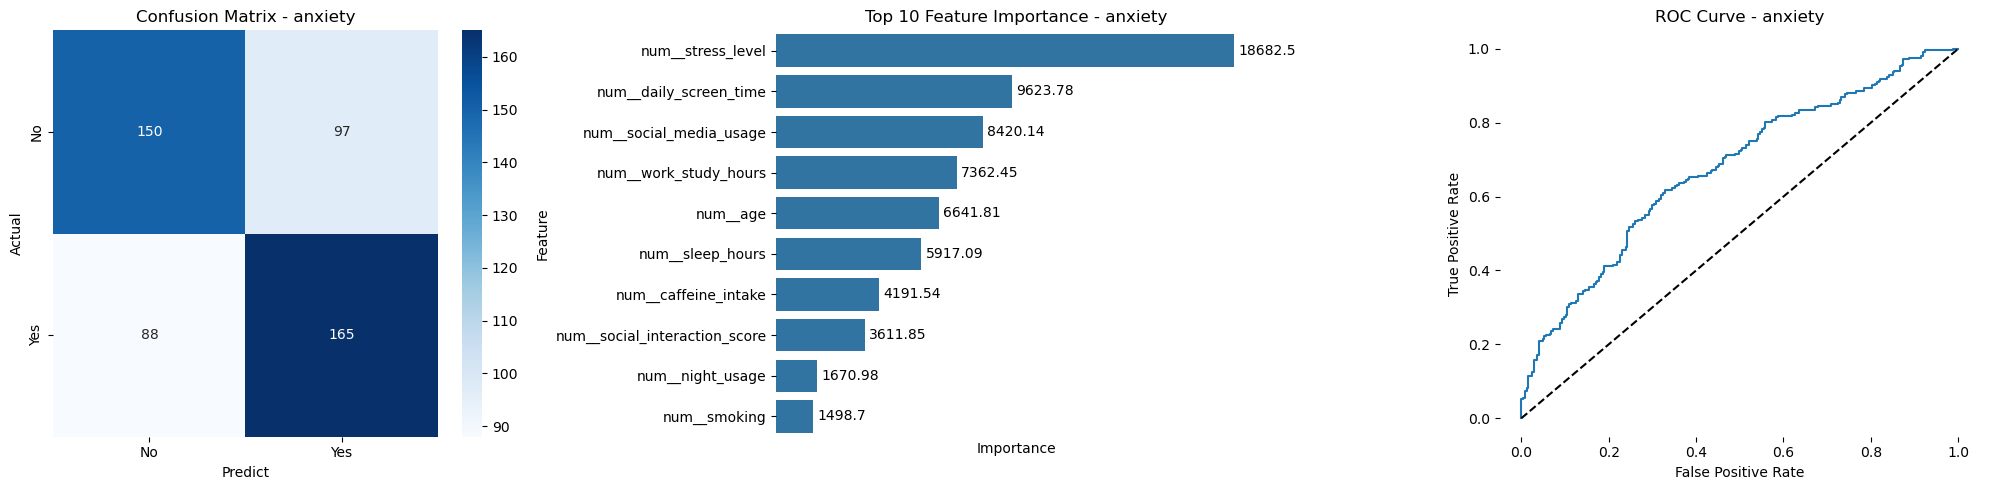


 Predict >> burnout 
Best F1 Score: 0.59
Best Params: {'n_estimators': 216, 'learning_rate': 0.0028663295947093915, 'num_leaves': 73, 'max_depth': 4}

 ==================== Evaluation ====================
f1_score (Test Set): 0.60
              precision    recall  f1-score   support

          No       0.60      0.52      0.56       242
         Yes       0.60      0.67      0.63       258

    accuracy                           0.60       500
   macro avg       0.60      0.60      0.59       500
weighted avg       0.60      0.60      0.60       500



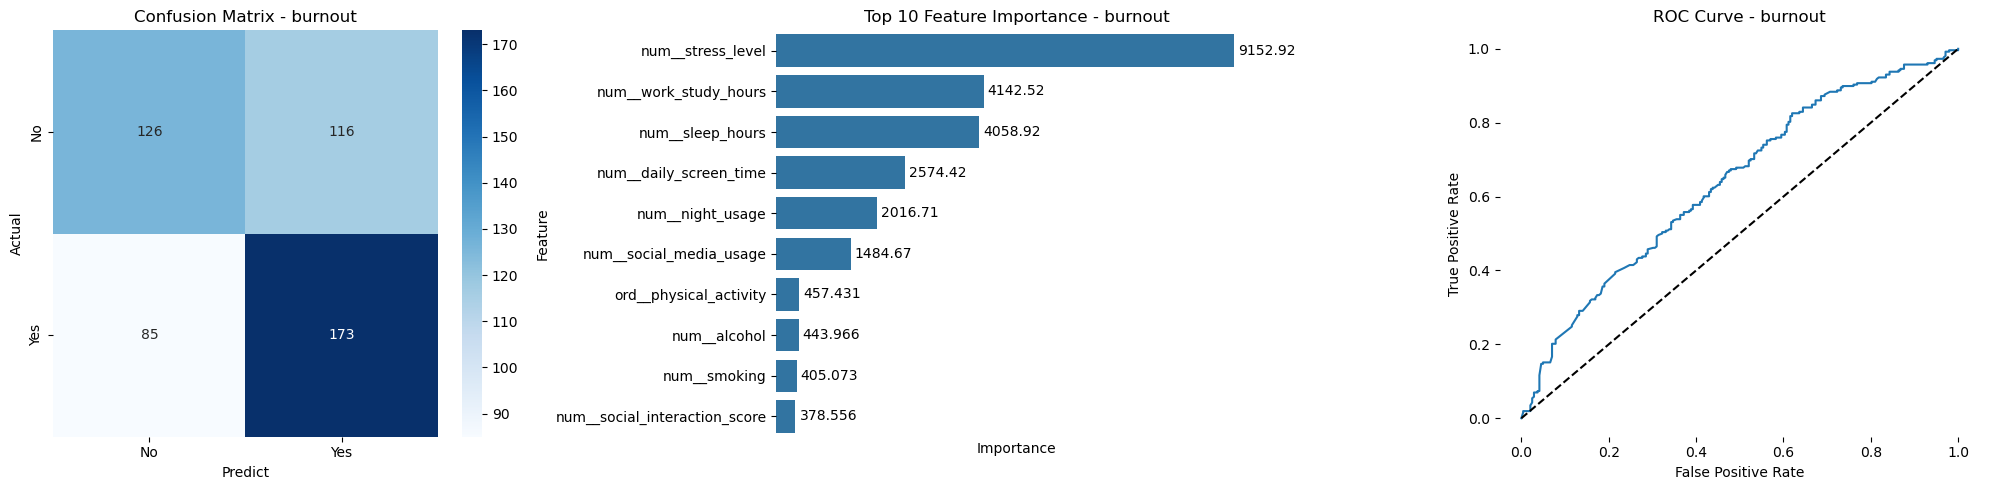

In [ ]:
# pipeline number feature
num_pipe = Pipeline([
    ('yj', PowerTransformer(method='yeo-johnson'))
])

# pipeline ordinal feature
ord_feature = ['physical_activity']
ord_pipe = Pipeline([
    ('ordinal', OrdinalEncoder(categories=[['Low','Medium','High']]))
    , ('scaler', StandardScaler())
])

# Create Column Transform Step
nom_feature = ['gender','occupation']
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, make_column_selector(dtype_include= np.number))
    , ('ord', ord_pipe, ord_feature)
    , ('nom', OneHotEncoder(handle_unknown='ignore'), nom_feature)
])

for y_col in y_list:
    
    le = LabelEncoder()
    df[y_col] = le.fit_transform(df[y_col])
    target_name = le.classes_
    
    x = df.drop(['depression','anxiety','burnout'], axis=1)
    y = df[y_col]

    x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=1, stratify=y)

    # Create Objective Function for Optuna
    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000)
            , 'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True)
            
            , 'num_leaves': trial.suggest_int('num_leaves', 20, 150)
            , 'max_depth': trial.suggest_int('max_depth', 3, 50)
            
            , 'class_weight': 'balanced'
            , 'random_state': 1
            , 'importance_type': 'gain'
        }

        # Create Pipeline
        current_pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('model', lgb.LGBMClassifier(**param))
        ])

        # Cross Validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
        scores = cross_val_score(current_pipe, x_train, y_train, cv=cv, scoring='f1_weighted', n_jobs=-1)
        
        return scores.mean()

    # Start Optimize
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, n_jobs=-1)
    print('\n', '='*50, '\n', f'Predict >> {y_col}', '\n', '='*50)
    

    # Print Best Params
    print(f"Best F1 Score: {study.best_value:0.2f}")
    print(f"Best Params: {study.best_params}")
    
    # Predict by Best Params
    best_model_params = study.best_params
    
    opt_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', lgb.LGBMClassifier(**best_model_params, random_state=1, importance_type='gain', verbosity=-1))
    ])

    opt_pipe.fit(x_train, y_train)
    current_pred = opt_pipe.predict(x_test)

    # Report
    print('\n', '='*20, 'Evaluation', '='*20)
    print(f"f1_score (Test Set): {f1_score(y_test, current_pred, average='weighted'):0.2f}")
    print(classification_report(y_test, current_pred, target_names=target_name))

    # Visualization
    fig, ax = plt.subplots(1,3,figsize=(20,5))

    # Heatmap
    sns.heatmap(
        confusion_matrix(y_test, current_pred), cmap='Blues'
        , xticklabels=target_name
        , yticklabels=target_name
        , annot=True
        , fmt='d'
        , ax=ax[0]
    )
    ax[0].set_xlabel('Predict')
    ax[0].set_ylabel('Actual')
    ax[0].set_title(f'Confusion Matrix - {y_col}')

    # Feature Importance
    feature_names = opt_pipe.named_steps['preprocessor'].get_feature_names_out()
    importances = opt_pipe.named_steps['model'].feature_importances_
    feature_important = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values(by='importance', ascending=False).head(10)
    feature_important_fig = sns.barplot(feature_important, x='importance', y='feature', ax=ax[1])
    ax[1].set_xlabel('Importance')
    ax[1].set_ylabel('Feature')
    ax[1].set_title(f'Top 10 Feature Importance - {y_col}')
    ax[1].set_xticks([])
    
    for container in ax[1].containers:
        ax[1].bar_label(container, padding=3)
    
    # ROC, AUC Curve
    y_probs = opt_pipe.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (area = 0.50)')
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].set_title(f'ROC Curve - {y_col}')
    
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()


**Key Finding**

**Feature Importance Analysis**: By analyzing the feature importance, I found the key factors that drive each model:

* **Stress Level:** This is the **top predictor** for all three conditions. It is especially significant for **Burnout and Anxiety**.
* **Lifestyle & Behavior Impacts:**
    * **Anxiety & Depression:** **Daily Screen Time** is the second most important factor for both models.
    * **Burnout:** Beyond stress, **Sleep Hours** and **Work/Study Hours** are major factors, showing a direct link between burnout and work-life balance.
    * **Social Media Usage:** This is a top 3 factor specifically for predicting **Anxiety**.

**Model Performance Evaluation**: Comparing the models' ability to predict results on the Test Set:

* **Best Performer:** The **Burnout model** achieved the highest performance with an **F1-Score of 0.60** and **60% accuracy**.
* **Predictive Balance:** Based on the Confusion Matrix:
    * The models are effective at identifying "Yes" cases. For example, the **Burnout model** correctly identified 173 out of 258 individuals.
    * The dataset is **well-balanced** (about 250 samples per class), resulting in consistent Macro and Weighted average scores between 0.60 and 0.64.
* **Classification Quality:** The **ROC Curves** for all models stay above the baseline, proving that the models are successfully learning patterns from the data to distinguish between different mental health states.